# Taller: Representaciones de Texto - Word Embeddings y Embedding Contextual
## Curso de Inteligencia Artificial
---

En este taller explorarás de forma práctica cómo los embeddings transforman palabras en vectores numéricos que capturan relaciones semánticas y sintácticas.

**OBJETIVO**:

- Completa cada sección escribiendo el código Python necesario para lograr los objetivos especificados.
- Usa las instrucciones y pistas en cada celda para guiarte en la solución.


## 1. Instalación de Dependencias

Primero, instalaremos las librerías necesarias:

In [1]:
# TODO: Instalar las siguientes librerías
# - gensim
# - nltk
# - scikit-learn
# - matplotlib
# - numpy
#
# INSTRUCCIONES:
# 1. Importa subprocess y sys
# 2. Crea una lista llamada 'librerías' con las librerías mencionadas
# 3. Usa un loop para instalar cada una con pip install
# 4. Imprime un mensaje de confirmación al final

import subprocess
import sys

librerías = ['gensim','nltk','scikit-learn','matplotlib','numpy']

for librería in librerías:
  print(f"Instalando {librería}...")
  subprocess.check_call([sys.executable, "-m", "pip", "install", librería])

print('✓ Todas las dependencias instaladas')


Instalando gensim...
Instalando nltk...
Instalando scikit-learn...
Instalando matplotlib...
Instalando numpy...
✓ Todas las dependencias instaladas


## 2. Conceptos Fundamentales

In [2]:
# TODO: Comparar One-Hot Encoding vs Dense Embeddings
#
# INSTRUCCIONES:
# 1. Define un vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
# 2. Crea un vector One-Hot para la primera palabra (todos ceros excepto el índice 0)
# 3. Crea un embedding denso usando números aleatorios (np.random.randn)
# 4. Imprime ambos vectores con sus características
#
# PISTAS:
# - Usa np.zeros() para crear el vector one-hot
# - Usa np.random.seed(42) para reproducibilidad
# - Usa np.random.randn() para crear embeddings densos

import numpy as np

vocabulario = ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']

# One-Hot para la primera palabra ('inteligencia')
one_hot = np.zeros(len(vocabulario), dtype=int)
one_hot[0] = 1

# Embedding denso aleatorio (reproducible)
np.random.seed(42)
embedding_denso = np.random.randn(5)  # dimensión 5 como ejemplo
print("=" * 70)
print("CONCEPTOS FUNDAMENTALES: ONE-HOT vs EMBEDDINGS")
print("=" * 70,"\n")

print('Vocabulario:', vocabulario)
print(f"Tamaño: {len(vocabulario)} \n")
print(f"One-Hot: {one_hot}")
print("Propiedades: Muy disperso, no captura semántica \n")

print(f"Embedding: {embedding_denso}")
print("Propiedades: Denso, captura semántica implícita")

CONCEPTOS FUNDAMENTALES: ONE-HOT vs EMBEDDINGS

Vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
Tamaño: 5 

One-Hot: [1 0 0 0 0]
Propiedades: Muy disperso, no captura semántica 

Embedding: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Propiedades: Denso, captura semántica implícita


## 3. Word2Vec - Entrenamiento Práctico

In [3]:
# TODO: Entrenar un modelo Word2Vec
#
# INSTRUCCIONES:
# 1. Importa Word2Vec de gensim
# 2. Importa funciones de nltk para tokenizar
# 3. Define un corpus de ejemplo sobre IA/ML (al menos 5 oraciones)
# 4. Tokeniiza el corpus en oraciones y palabras
# 5. Entrena Word2Vec con los parámetros:
#    - vector_size=50
#    - window=5
#    - min_count=1
#    - sg=1 (Skip-gram)
# 6. Imprime información del modelo entrenado
#
# PISTAS:
# - Usa sent_tokenize para separar oraciones
# - Usa word_tokenize para separar palabras
# - Descarga los recursos necesarios de nltk con nltk.download()

from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

# Descargamos los recursos necesarios para tokenización (silencioso)
nltk.download('punkt')
nltk.download('punkt_tab') # Added as per error message suggestion

# Corpus de ejemplo (mínimo 5 oraciones) — en español y con las palabras del vocabulario
corpus = '''
La inteligencia artificial y el aprendizaje automático transforman los datos en conocimiento.
Los modelos de máquina aprenden patrones a partir de grandes cantidades de datos.
El aprendizaje profundo usa redes neuronales para resolver tareas complejas.
El campo de la inteligencia artificial incluye procesamiento de lenguaje y visión por computadora.
Los embeddings permiten representar palabras y conceptos en vectores numéricos.
'''

# Tokenizamos por oraciones y por palabras (normalizamos a minúsculas)
oraciones = sent_tokenize(corpus, language='spanish')
tokens = [word_tokenize(oracion.lower()) for oracion in oraciones]

# Entrenamos Word2Vec con los parámetros solicitados
print("Entrenando Word2Vec")
modelo = Word2Vec(sentences=tokens, vector_size=50, window=5, min_count=1, sg=1)
print("✓ Modelo entrenado")
print(f"Vocabulario: {len(modelo.wv.index_to_key)} palabras")
print(f"Dimensión: {modelo.vector_size}")


# 1. Encontrar las palabras más parecidas a inteligencia
similares = modelo.wv.most_similar("inteligencia", topn=5)

print("Palabras similares a 'inteligencia':")
for palabra, puntuacion in similares:
    print(f"{palabra}: {puntuacion:.4f}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Entrenando Word2Vec
✓ Modelo entrenado
Vocabulario: 44 palabras
Dimensión: 50
Palabras similares a 'inteligencia':
para: 0.2655
automático: 0.2559
transforman: 0.2349
en: 0.2271
complejas: 0.2014


## 4. Visualización con t-SNE

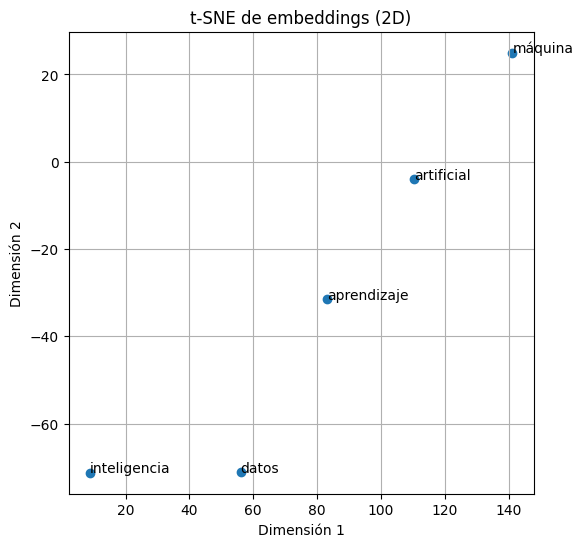

In [9]:
# TODO: Visualizar embeddings con t-SNE
#
# INSTRUCCIONES:
# 1. Selecciona 5 palabras que existan en el modelo entrenado
# 2. Obtén sus vectores del modelo
# 3. Usa t-SNE para reducir a 2 dimensiones (perplexity=2)
# 4. Crea un gráfico scatter con los puntos
# 5. Añade anotaciones con los nombres de las palabras
# 6. Añade título y etiquetas a los ejes
#
# PISTAS:
# - TSNE viene de sklearn.manifold
# - Usa plt.scatter() para graficar los puntos
# - Usa plt.annotate() para añadir etiquetas
# - Usa fit_transform() para ajustar y transformar los dados

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np # Import numpy for array conversion

# Selecciona palabras que existan en tu modelo
palabras = ['inteligencia', 'artificial', 'aprendizaje', 'datos', 'máquina']
palabras_existentes = [p for p in palabras if p in modelo.wv]

if len(palabras_existentes) < 2:
    print('No hay suficientes palabras del vocabulario para graficar. Asegúrate de entrenar el modelo.')
else:
    vectores = [modelo.wv[p] for p in palabras_existentes]
    # Convertir la lista de vectores a un array de NumPy
    vectores_np = np.array(vectores)
    tsne = TSNE(n_components=2, perplexity=2, random_state=42)
    X_tsne = tsne.fit_transform(vectores_np)

    plt.figure(figsize=(6,6))
    plt.scatter(X_tsne[:,0], X_tsne[:,1])
    for i, palabra in enumerate(palabras_existentes):
        plt.annotate(palabra, (X_tsne[i,0], X_tsne[i,1]))
    plt.title('t-SNE de embeddings (2D)')
    plt.xlabel('Dimensión 1')
    plt.ylabel('Dimensión 2')
    plt.grid(True)
    plt.show()


## 5. Clasificación de Textos con Embeddings

In [8]:
# TODO: Clasificar textos usando embeddings
#
# INSTRUCCIONES:
# 1. Define una función que calcule el embedding promedio de un texto
#    - Tokeniza el texto
#    - Obtén vectores de palabras que existan en el modelo
#    - Retorna el promedio de esos vectores
# 2. Crea un dataset con 4 textos de ejemplo y sus etiquetas (positivo=1, negativo=0)
# 3. Obtén los embeddings promedios para cada texto
# 4. Entrena un clasificador LogisticRegression
# 5. Evalúa la precisión en los datos de entrenamiento
# 6. Haz una predicción en un nuevo texto de prueba
#
# PISTAS:
# - np.mean() para promediar vectores
# - LogisticRegression de sklearn.linear_model
# - clf.fit() para entrenar
# - clf.score() para evaluar
# - clf.predict() para predecir

from sklearn.linear_model import LogisticRegression
import numpy as np
import re
from nltk.tokenize import word_tokenize

def get_embedding_avg(texto, modelo):
    tokens = word_tokenize(texto.lower(), language='spanish')
    tokens = [t for t in tokens if re.match(r'^[a-záéíóúüñ]+$', t)]
    vectores = [modelo[t] for t in tokens if t in modelo]

    if len(vectores) == 0:
        return np.zeros(modelo.vector_size)

    return np.mean(vectores, axis=0)

# Dataset de ejemplo (puedes crear tus propios ejemplos)
textos = [
    "el sistema inteligente fue excelente y útil",
    "el modelo produjo resultados malos y deficientes",
    "la inteligencia artificial es eficiente y coherente",
    "el entrenamiento fue deficiente y generó errores"
]  # Completa con 4 textos
etiquetas = [1, 0, 1, 0]  # Completa con sus etiquetas (0 o 1)

# Embeddings promedio
X = np.array([get_embedding_avg(texto, modelo.wv) for texto in textos])
y = np.array(etiquetas)

# Entrenamiento
clf = LogisticRegression(random_state=42)
clf.fit(X, y)
print("✓ Clasificador entrenado")

# Evaluación
precision = clf.score(X, y)
print(f"Precisión:  {round(float(precision), 2)}")

# Predicción en nuevo texto
nuevo_texto = "el modelo fue útil y excelente"
embedding_nuevo = get_embedding_avg(nuevo_texto, modelo.wv).reshape(1, -1)
prediccion = clf.predict(embedding_nuevo)[0]
probabilidad = clf.predict_proba(embedding_nuevo)[0]

print("\nTexto:", nuevo_texto)
print("Predicción:", "positivo" if prediccion == 1 else "negativo")

✓ Clasificador entrenado
Precisión:  0.75

Texto: el modelo fue útil y excelente
Predicción: negativo


## 6. Conclusiones

En este taller hemos aprendido:
- Conceptos fundamentales de embeddings
- Entrenamiento de Word2Vec
- Visualización y análisis
- Aplicación en clasificación de textos

¡Felicidades por completar el taller!